# 04 · Exploratory Analysis
## NHANES 2017–March 2020 Women's CKM Phenotyping Project

---

**Author:** Alexandra Velez, MD  
**Input:** `data/processed/ckm_features.csv` — 1,603 women aged 20–44  
**Last updated:** 2026

---

### Purpose of this notebook

This notebook performs exploratory analysis of the complete CKM feature 
matrix produced in notebook 03. The goals are:

1. **Characterize the analytical sample** — descriptive statistics across 
   all 12 clustering features by APO status
2. **Examine biomarker distributions** — identify skewness, outliers, and 
   distributional patterns that will inform preprocessing decisions in 
   notebook 05
3. **Assess feature correlations** — identify collinear features that may 
   need special handling in k-means clustering
4. **Quantify medication confounder impact** — determine whether medicated 
   women should be excluded from clustering or retained with flags
5. **Define missingness strategy** — decide how to handle missing values 
   before clustering

The outputs of this notebook directly inform the clustering design in 
notebook 05 — particularly the imputation strategy, feature scaling 
approach, and the decision on medicated women.

---

### Central clinical question

> Among reproductive-age women aged 20–44, do those with adverse pregnancy 
> outcomes — particularly gestational diabetes — already show distinct early 
> cardiometabolic biomarker profiles compared to women without APOs?

This notebook provides the descriptive evidence that motivates the 
clustering analysis. If women with GDM history already show measurable 
biomarker differences at ages 20–44, the clustering in notebook 05 is 
clinically justified.

---
## Section 1 · Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
INPUT_PATH = Path('../data/processed/ckm_features.csv')
CLASS_PATH = Path('../data/processed/feature_classification_full.csv')
FIG_DIR    = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

# ── Plot style ─────────────────────────────────────────────────────────────
# Okabe-Ito colorblind-safe palette — consistent with notebook 01
COLORS = {
    'no_apo':    '#0072B2',   # blue — no APOs
    'macs_only': '#56B4E9',   # sky blue — macrosomia only
    'gdm_only':  '#E69F00',   # orange — GDM only
    'gdm_macs':  '#D55E00',   # vermillion — GDM + macrosomia
    'never_preg':'#999999',   # grey — never pregnant
    'highlight': '#CC79A7',   # pink — highlights
}

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print('Setup complete.')
print(f'  Input:   {INPUT_PATH}')
print(f'  Figures: {FIG_DIR}')

Setup complete.
  Input:   ../data/processed/ckm_features.csv
  Figures: ../figures


---
## Section 2 · Load & Validate

In [6]:
# ── Load CKM feature matrix ────────────────────────────────────────────────
df = pd.read_csv(INPUT_PATH, index_col='SEQN')

assert df.shape == (1603, 59), \
    f'Unexpected shape {df.shape} — expected (1603, 59)'
assert df.index.name == 'SEQN', \
    'SEQN is not the index'

print(f'✓ CKM feature matrix loaded: {df.shape}')
print(f'  Age range: {df["RIDAGEYR"].min():.0f}–{df["RIDAGEYR"].max():.0f} years')

# ── Load feature classification ────────────────────────────────────────────
df_class = pd.read_csv(CLASS_PATH)

clustering_features = df_class.loc[
    df_class['clustering'] == True, 'feature'
].tolist()

repro_features = ['Age_Menarche', 'Parity', 'Pregnancy_Loss', 'APO_Score']
ckm_features   = [f for f in clustering_features if f not in repro_features]

print(f'\n✓ Feature classification loaded')
print(f'  Total clustering features: {len(clustering_features)}')
print(f'  Reproductive: {repro_features}')
print(f'  CKM biomarkers: {ckm_features}')

# ── Define APO (Adverse pregnancy outcomes) subgroups ───────────────────────────────────────────────────
# APO_Score: 0=no APOs, 1=macrosomia only, 2=GDM only, 3=GDM+macrosomia
# Ever_Pregnant=0 → never pregnant (APO_Score is NaN)

apo_labels = {
    'never_pregnant': df['Ever_Pregnant'] == 0.0,
    'no_apo':         df['APO_Score'] == 0.0,
    'macs_only':      df['APO_Score'] == 1.0,
    'gdm_only':       df['APO_Score'] == 2.0,
    'gdm_macs':       df['APO_Score'] == 3.0,
}

print(f'\nAPO subgroup sizes:')
for label, mask in apo_labels.items():
    print(f'  {label:<20} {mask.sum():>5,}  ({mask.sum()/len(df)*100:.1f}%)')

✓ CKM feature matrix loaded: (1603, 59)
  Age range: 20–44 years

✓ Feature classification loaded
  Total clustering features: 12
  Reproductive: ['Age_Menarche', 'Parity', 'Pregnancy_Loss', 'APO_Score']
  CKM biomarkers: ['HbA1c', 'BMI', 'Waist', 'Mean_SBP', 'Mean_DBP', 'eGFR', 'HDL', 'Glucose']

APO subgroup sizes:
  never_pregnant         451  (28.1%)
  no_apo                 813  (50.7%)
  macs_only              114  (7.1%)
  gdm_only               104  (6.5%)
  gdm_macs                30  (1.9%)


---
## Section 3 · Descriptive Statistics by APO Status

Biomarker distributions are compared across five subgroups defined by 
APO history. The primary comparison of interest is GDM history (APO_Score 
≥ 2) versus no APOs (APO_Score = 0) among ever-pregnant women — the 
central question of this project.

Never-pregnant women are included for context but are not the primary 
comparison group. Their biomarker profiles reflect reproductive history 
absence rather than APO exposure and should be interpreted separately.

All statistics are unweighted — clustering uses the unweighted analytical 
sample. Weighted estimates for population-level prevalence claims were 
established in notebook 01.

In [7]:
# ── Descriptive statistics by APO status ──────────────────────────────────
# For each CKM clustering feature, report mean ± SD and median [IQR]
# by APO subgroup

biomarker_labels = {
    'HbA1c':    'HbA1c (%)',
    'BMI':      'BMI (kg/m²)',
    'Waist':    'Waist (cm)',
    'Mean_SBP': 'Systolic BP (mmHg)',
    'Mean_DBP': 'Diastolic BP (mmHg)',
    'eGFR':     'eGFR (mL/min/1.73m²)',
    'HDL':      'HDL (mg/dL)',
    'Glucose':  'Glucose (mg/dL)',
}

subgroup_order = [
    'never_pregnant', 'no_apo', 'macs_only', 'gdm_only', 'gdm_macs'
]

subgroup_labels = {
    'never_pregnant': 'Never\nPregnant\n(n=451)',
    'no_apo':         'No APOs\n(n=813)',
    'macs_only':      'Macrosomia\nOnly\n(n=114)',
    'gdm_only':       'GDM\nOnly\n(n=104)',
    'gdm_macs':       'GDM +\nMacrosomia\n(n=30)',
}

print('=== Descriptive Statistics by APO Status ===\n')
print(f'  {"Feature":<12} {"Subgroup":<22} {"N":>5} {"Mean":>8} '
      f'{"SD":>7} {"Median":>8} {"IQR":>14}')
print(f'  {"─"*12} {"─"*22} {"─"*5} {"─"*8} {"─"*7} {"─"*8} {"─"*14}')

desc_results = []

for feat, label in biomarker_labels.items():
    first = True
    for sg in subgroup_order:
        mask   = apo_labels[sg]
        values = df.loc[mask, feat].dropna()
        n      = len(values)

        if n == 0:
            continue

        mean   = values.mean()
        sd     = values.std()
        median = values.median()
        q1     = values.quantile(0.25)
        q3     = values.quantile(0.75)

        feat_label = label if first else ''
        first      = False

        print(f'  {feat_label:<12} {subgroup_labels[sg].replace(chr(10), " "):<22} '
              f'{n:>5,} {mean:>8.1f} {sd:>7.1f} {median:>8.1f} '
              f'[{q1:.1f}–{q3:.1f}]')

        desc_results.append({
            'feature':   feat,
            'label':     label,
            'subgroup':  sg,
            'n':         n,
            'mean':      round(mean, 2),
            'sd':        round(sd, 2),
            'median':    round(median, 2),
            'q1':        round(q1, 2),
            'q3':        round(q3, 2),
        })

    print()

desc_df = pd.DataFrame(desc_results)

=== Descriptive Statistics by APO Status ===

  Feature      Subgroup                   N     Mean      SD   Median            IQR
  ──────────── ────────────────────── ───── ──────── ─────── ──────── ──────────────
  HbA1c (%)    Never Pregnant (n=451)   428      5.3     0.6      5.3 [5.0–5.5]
               No APOs (n=813)          771      5.4     0.6      5.3 [5.1–5.5]
               Macrosomia Only (n=114)   110      5.5     0.9      5.3 [5.1–5.7]
               GDM Only (n=104)         103      5.8     1.2      5.4 [5.2–5.9]
               GDM + Macrosomia (n=30)    29      6.2     1.6      5.6 [5.3–6.1]

  BMI (kg/m²)  Never Pregnant (n=451)   451     29.0     9.6     26.6 [21.7–33.5]
               No APOs (n=813)          808     30.5     8.5     29.2 [24.1–35.0]
               Macrosomia Only (n=114)   113     31.6     8.6     29.5 [26.1–36.1]
               GDM Only (n=104)         103     31.2     6.7     30.1 [26.9–35.5]
               GDM + Macrosomia (n=30)    30     36.

### Descriptive statistics — key findings

The descriptive analysis reveals a clear and clinically meaningful gradient 
in cardiometabolic biomarkers across APO subgroups. Women with GDM history 
show measurably worse metabolic profiles than women without APOs — even at 
ages 20–44, before overt cardiovascular disease has had time to develop.

**Strongest gradients (APO burden → worse profile):**

- **HbA1c** increases from 5.4% (no APOs) to 6.2% (GDM + macrosomia) — 
  a clinically meaningful difference. Women with GDM + macrosomia approach 
  the prediabetes threshold (HbA1c ≥ 5.7%) on average.
- **Glucose** increases from 90.3 mg/dL (no APOs) to 110.2 mg/dL 
  (GDM + macrosomia) — approaching the impaired fasting glucose threshold 
  (≥ 100 mg/dL) in the highest APO burden group.
- **BMI** and **waist circumference** both increase monotonically with APO 
  burden — consistent with the known association between obesity and GDM.
- **HDL** decreases monotonically with APO burden — lower HDL is an 
  independent cardiometabolic risk marker.

**Weaker gradients:**

- **Blood pressure** shows a modest gradient that attenuates in the 
  GDM + macrosomia group — likely reflecting antihypertensive medication 
  use and the small sample size (n=30) in the highest burden group.
- **eGFR** shows no meaningful gradient — kidney function appears preserved 
  at this age, consistent with the expectation that renal consequences of 
  metabolic disease take decades to manifest.

**Clinical interpretation:**

These descriptive differences provide the empirical justification for the 
clustering analysis in notebook 05. Women with GDM history are not simply 
"at risk" in a theoretical sense — they already show measurable early 
cardiometabolic dysregulation at ages 20–44. The question for clustering 
is whether these differences are sufficient to produce distinct, stable 
phenotypic clusters when all 12 features are considered jointly.

**Note on never-pregnant women:**
Never-pregnant women show lower BMI, waist, and glucose than even the 
no-APO group — likely reflecting demographic differences rather than 
a protective reproductive effect. This group will be analyzed separately 
in the clustering interpretation.

**Important caveat — blood pressure interpretation:**
Blood pressure in reproductive-age women is physiologically modified 
by pregnancy — values drop in the first and second trimester and 
return to baseline postpartum. The 67 currently pregnant women in 
the analytical sample (RHD143=1) may have artificially low BP readings 
reflecting physiological pregnancy vasodilation rather than their 
habitual blood pressure. Additionally, the absence of hypertensive 
disorders of pregnancy data means women with a history of gestational 
hypertension or preeclampsia cannot be identified — their current 
normotensive readings may underestimate their true vascular risk. 
Blood pressure differences across APO subgroups should therefore be 
interpreted cautiously and considered secondary to the glycemic and 
adiposity findings.

---
## Section 4 · Biomarker Distributions by APO Status

Violin plots show the full distribution of each CKM biomarker across 
APO subgroups — more informative than means alone as they reveal 
skewness, multimodality, and overlap between groups. The gradient 
identified in Section 3 is visualized here for the primary comparison: 
ever-pregnant women stratified by APO burden.

Never-pregnant women are shown for reference only and are visually 
distinguished from the APO subgroups.

In [9]:
# ── Subgroup plot configuration ────────────────────────────────────────────
subgroup_plot_order  = ['never_pregnant', 'no_apo', 'macs_only', 'gdm_only', 'gdm_macs']

subgroup_plot_labels = [
    'Never\nPregnant',
    'No APOs',
    'Macrosomia\nOnly',
    'GDM\nOnly',
    'GDM +\nMacrosomia',
]

subgroup_colors = [
    COLORS['never_preg'],
    COLORS['no_apo'],
    COLORS['macs_only'],
    COLORS['gdm_only'],
    COLORS['gdm_macs'],
]

biomarker_labels = {
    'HbA1c':    'HbA1c (%)',
    'BMI':      'BMI (kg/m²)',
    'Waist':    'Waist Circumference (cm)',
    'Mean_SBP': 'Systolic BP (mmHg)',
    'Mean_DBP': 'Diastolic BP (mmHg)',
    'eGFR':     'eGFR (mL/min/1.73m²)',
    'HDL':      'HDL Cholesterol (mg/dL)',
    'Glucose':  'Fasting Glucose (mg/dL)',
}

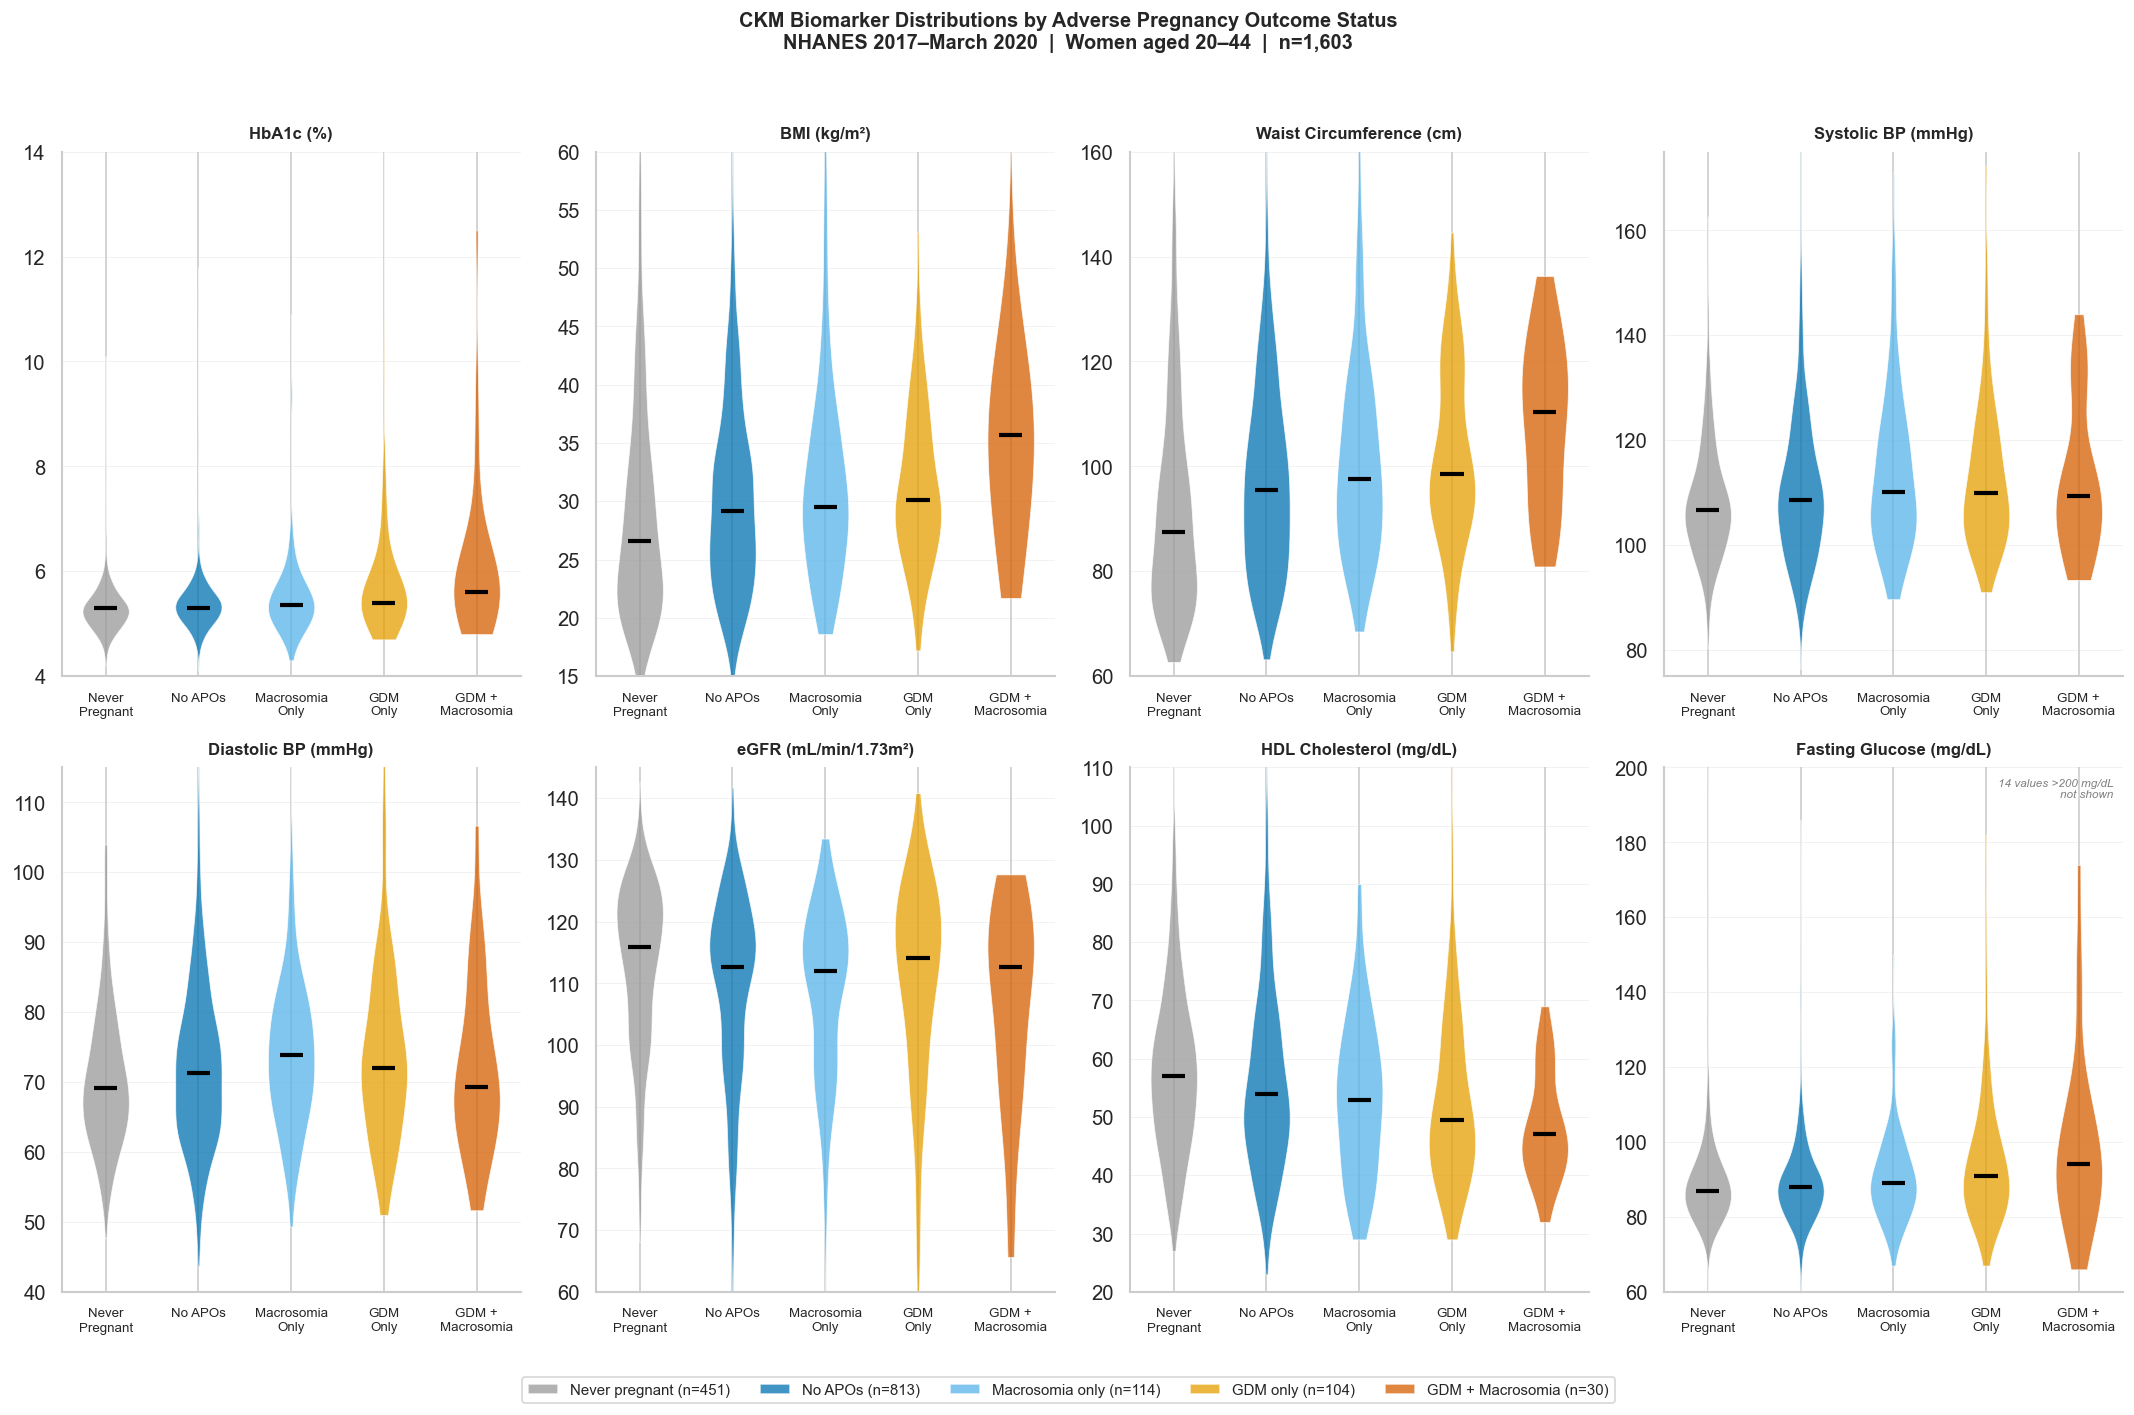

✓ Figure saved: biomarker_distributions_by_apo.png
  Note: 14 glucose values >200 mg/dL excluded from display only — not from analysis


In [10]:
# ── Biomarker distributions by APO status — improved ──────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 11))
axes = axes.flatten()

# Y-axis limits to improve readability
y_limits = {
    'HbA1c':    (4.0,  14.0),
    'BMI':      (15.0, 60.0),
    'Waist':    (60.0, 160.0),
    'Mean_SBP': (75.0, 175.0),
    'Mean_DBP': (40.0, 115.0),
    'eGFR':     (60.0, 145.0),
    'HDL':      (20.0, 110.0),
    'Glucose':  (60.0, 200.0),   # capped at 200 — extreme outliers excluded
}

# Note for glucose cap
glucose_n_excluded = (df['Glucose'] > 200).sum()

for i, (feat, label) in enumerate(biomarker_labels.items()):
    ax = axes[i]

    plot_data   = []
    plot_colors = []
    n_labels    = []

    for sg, color in zip(subgroup_plot_order, subgroup_colors):
        values = df.loc[apo_labels[sg], feat].dropna().values
        # Cap glucose for display only — does not affect data
        if feat == 'Glucose':
            values = values[values <= 200]
        plot_data.append(values)
        plot_colors.append(color)
        n_labels.append(f'n={len(values)}')

    # Violin plot
    parts = ax.violinplot(plot_data,
                          positions=range(len(plot_data)),
                          showmedians=True,
                          showextrema=False)

    for pc, color in zip(parts['bodies'], plot_colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.75)
        pc.set_edgecolor('white')
        pc.set_linewidth(0.5)

    parts['cmedians'].set_color('black')
    parts['cmedians'].set_linewidth(2.5)

    # X-axis labels
    ax.set_xticks(range(len(subgroup_plot_labels)))
    ax.set_xticklabels(subgroup_plot_labels, fontsize=8)

    # Title — no redundant y-axis label
    ax.set_title(label, fontsize=10, fontweight='bold', pad=8)
    ax.set_ylabel('')

    # Y-axis limits
    if feat in y_limits:
        ax.set_ylim(y_limits[feat])

    # Add glucose cap note
    if feat == 'Glucose' and glucose_n_excluded > 0:
        ax.text(0.98, 0.98,
                f'{glucose_n_excluded} values >200 mg/dL\nnot shown',
                transform=ax.transAxes,
                ha='right', va='top',
                fontsize=7, color='gray', style='italic')

    # Clean spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.3, linewidth=0.5)

# ── Legend ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['never_preg'], alpha=0.75,
          label=f'Never pregnant (n=451)'),
    Patch(facecolor=COLORS['no_apo'],     alpha=0.75,
          label=f'No APOs (n=813)'),
    Patch(facecolor=COLORS['macs_only'],  alpha=0.75,
          label=f'Macrosomia only (n=114)'),
    Patch(facecolor=COLORS['gdm_only'],   alpha=0.75,
          label=f'GDM only (n=104)'),
    Patch(facecolor=COLORS['gdm_macs'],   alpha=0.75,
          label=f'GDM + Macrosomia (n=30)'),
]

fig.legend(handles=legend_elements,
           loc='lower center',
           ncol=5,
           fontsize=9,
           framealpha=0.9,
           edgecolor='lightgray',
           bbox_to_anchor=(0.5, -0.04))

# ── Title ──────────────────────────────────────────────────────────────────
fig.suptitle(
    'CKM Biomarker Distributions by Adverse Pregnancy Outcome Status\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,603',
    fontsize=12, fontweight='bold', y=1.02
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'biomarker_distributions_by_apo.png',
            dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print('✓ Figure saved: biomarker_distributions_by_apo.png')
if glucose_n_excluded > 0:
    print(f'  Note: {glucose_n_excluded} glucose values >200 mg/dL '
          f'excluded from display only — not from analysis')

---
## Section 5 · Feature Correlation Analysis

Correlation analysis among the 12 clustering features serves two purposes:

1. **Identify collinear features** — highly correlated features 
   (|r| > 0.7) contribute redundant information to k-means distance 
   calculations, potentially over-weighting certain dimensions
2. **Understand feature relationships** — correlations between 
   reproductive and CKM features provide early evidence for the 
   APO-CKM hypothesis

### Why Spearman correlation is used rather than Pearson

Two correlation methods are commonly used in data analysis. **Pearson 
correlation** measures the strength of a strictly linear relationship 
between two variables and assumes both are continuous, approximately 
normally distributed, and free of extreme outliers. **Spearman 
correlation** is less restrictive — it measures whether two variables 
move together in the same direction (one increases as the other 
increases, or vice versa) without requiring the relationship to be 
perfectly linear. It does this by replacing raw values with their rank 
order before computing the correlation, making it insensitive to 
extreme outliers and non-normal distributions.

Spearman is the correct choice here for three reasons:

**1. Several biomarkers are right-skewed with extreme outliers.** 
The violin plots in Section 4 show that glucose, HbA1c, and BMI all 
have long right tails driven by women with diabetes or severe obesity. 
A single extreme glucose value of 350 mg/dL can artificially distort 
a Pearson correlation — Spearman is unaffected because it only cares 
about rank order, not raw values.

**2. Three of the 12 clustering features are ordinal or count 
variables.** APO_Score takes only four values (0, 1, 2, 3). Gravidity 
and Parity are counts top-coded at 11 and 5 respectively. Pearson 
correlation assumes truly continuous variables — applying it to 
APO_Score would violate this assumption. Spearman handles ordinal 
data naturally.

**3. The relationships of interest may not be linear.** The increase 
in HbA1c from APO_Score 0 to 1 may not be the same magnitude as the 
increase from 2 to 3. Spearman captures the monotonic trend — higher 
APO burden tends toward higher HbA1c — regardless of whether the 
relationship follows a perfectly straight line.

To summarize, Pearson is more powerful when its assumptions are met. 
Spearman is more appropriate when they are not. In this dataset, Spearman
is more robust to the non-normal distributions and outliers observed in Section 4, 
and appropriate for both continuous and ordinal features like 
APO_Score and Gravidity.

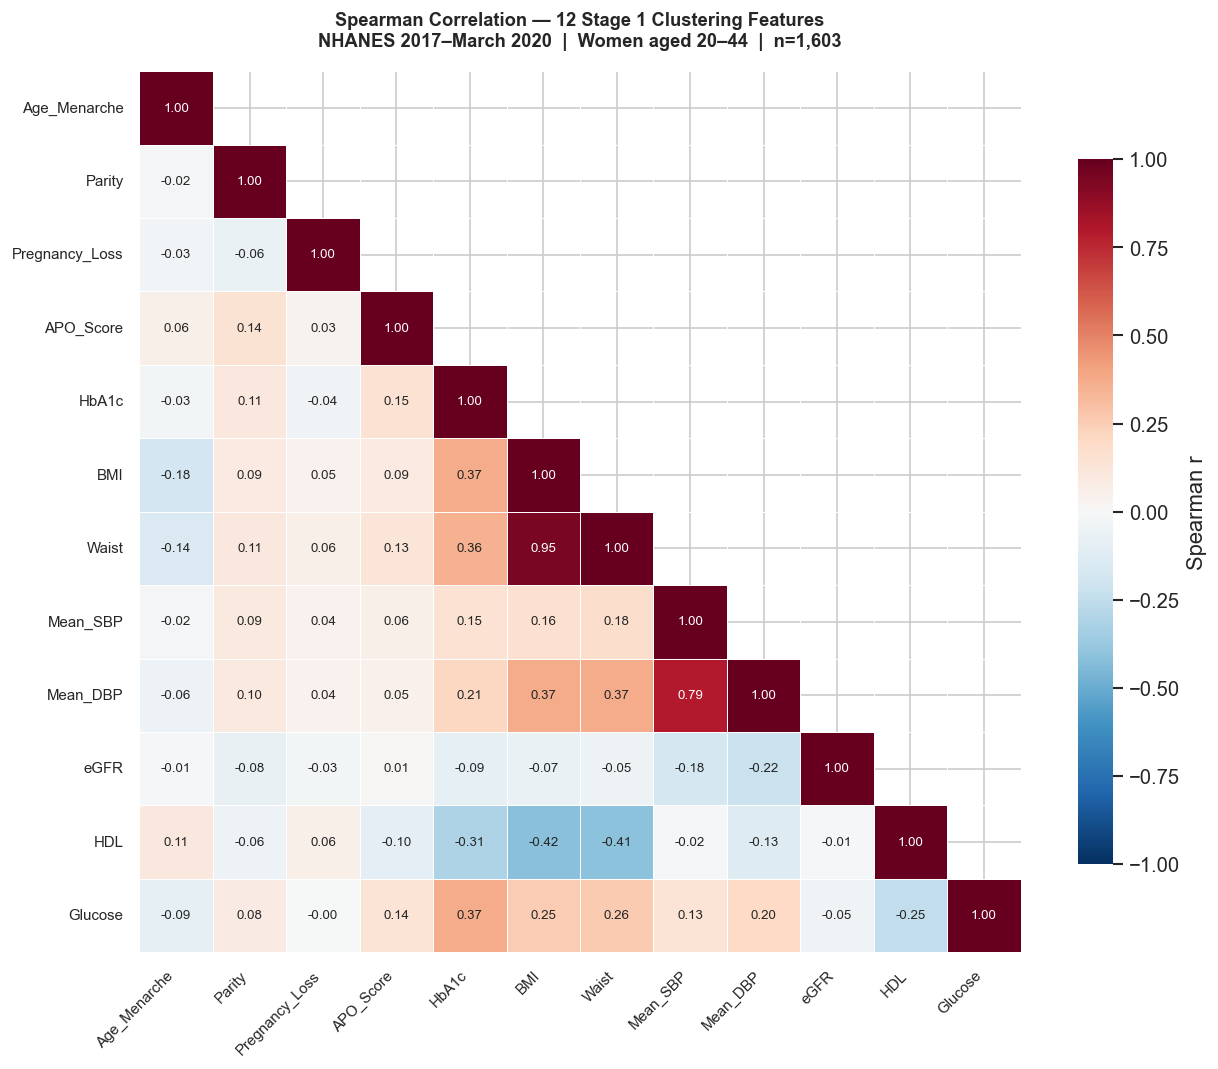

✓ Figure saved: correlation_heatmap.png

High correlations (|r| > 0.5):
  Feature 1       Feature 2            r
  ─────────────── ─────────────── ──────
  BMI             Waist             0.95 ⚠️
  Mean_SBP        Mean_DBP          0.79 ⚠️

  ⚠️  |r| > 0.7 warrants attention for clustering


In [11]:
# ── Correlation analysis — 12 clustering features ─────────────────────────
# Spearman correlation on complete cases only

corr_features = clustering_features  # 12 features defined in Section 2

# Compute Spearman correlation matrix
corr_matrix = df[corr_features].corr(method='spearman')

# ── Heatmap ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))

# Mask upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 8},
    ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Spearman r'}
)

ax.set_title(
    'Spearman Correlation — 12 Stage 1 Clustering Features\n'
    'NHANES 2017–March 2020  |  Women aged 20–44  |  n=1,603',
    fontsize=11, fontweight='bold', pad=15
)

# Rotate labels
ax.set_xticklabels(ax.get_xticklabels(),
                   rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(),
                   rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'correlation_heatmap.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Figure saved: correlation_heatmap.png')

# ── Flag high correlations ─────────────────────────────────────────────────
print('\nHigh correlations (|r| > 0.5):')
print(f'  {"Feature 1":<15} {"Feature 2":<15} {"r":>6}')
print(f'  {"─"*15} {"─"*15} {"─"*6}')

for i in range(len(corr_features)):
    for j in range(i+1, len(corr_features)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            flag = ' ⚠️' if abs(r) > 0.7 else ''
            print(f'  {corr_features[i]:<15} {corr_features[j]:<15} '
                  f'{r:>6.2f}{flag}')

print(f'\n  ⚠️  |r| > 0.7 warrants attention for clustering')

### Correlation findings

Spearman correlations were computed across all 12 Stage 1 clustering 
features — 4 reproductive (Age_Menarche, Parity, Pregnancy_Loss, 
APO_Score) and 8 CKM biomarkers (HbA1c, BMI, Waist, Mean_SBP, 
Mean_DBP, eGFR, HDL, Glucose).

**Two feature pairs exceed the |r| > 0.7 collinearity threshold:**

**BMI ↔ Waist (r = 0.95):**
Both capture adiposity but through different measurements. Including 
both would double-weight adiposity in k-means distance calculations, 
risking clusters driven primarily by body size rather than the full 
CKM profile. BMI is retained as the more standard clinical measure; 
Waist is dropped from clustering but retained for descriptive 
characterization.

**Mean_SBP ↔ Mean_DBP (r = 0.79):**
Systolic and diastolic pressure rise together in hypertension — 
including both double-weights the vascular dimension. Mean_SBP is 
retained as the single BP feature for this analysis.

While Mean Arterial Pressure (MAP = (SBP + 2×DBP) / 3) is 
considered a more clinically precise measure of overall tissue 
perfusion and end-organ health, SBP is the established gold standard 
for long-term cardiovascular risk prediction and remains an 
exceptionally strong independent predictor of heart disease and 
stroke. Given that this project's central question concerns early 
cardiometabolic risk in reproductive-age women, SBP is the more 
appropriate single BP feature for clustering. Mean_DBP is dropped 
from the clustering feature set but retained for descriptive 
characterization.

**Reproductive features show low inter-correlation — a key design 
validation:**
The previous feature set included Gravidity and Parity (r = 0.78), 
which presented the same double-weighting problem. Replacing Gravidity 
with Pregnancy_Loss (Gravidity − Parity) resolves this entirely — 
Parity and Pregnancy_Loss now correlate at only r = −0.06, confirming 
they capture independent clinical dimensions: delivery burden versus 
pregnancy loss burden. Age_Menarche and APO_Score also show weak 
correlations with all other features (|r| ≤ 0.15).

**APO_Score shows its strongest associations with HbA1c (r = 0.15) 
and Waist (r = 0.13)** — directionally consistent with the metabolic 
APO literature, and weak enough to confirm APO_Score adds signal the 
CKM biomarkers alone do not capture.

**Features flagged for removal before clustering in notebook 05:**
Waist (collinear with BMI, r = 0.95) and Mean_DBP (collinear with 
Mean_SBP, r = 0.79) will be dropped at the start of notebook 05 
based on these findings, reducing the clustering feature set from 
12 to 10: Age_Menarche, Parity, Pregnancy_Loss, APO_Score, HbA1c, 
BMI, Mean_SBP, eGFR, HDL, Glucose.